# Artista

El objetivo de esta sección es analizar las características de los artistas presentes en el conjunto de datos y explorar posibles patrones relacionados con su popularidad, diversidad musical y especialización.

Las principales preguntas que se buscan responder son:

- ¿Los artistas mantienen un estilo musical consistente entre sus canciones?
- ¿Existen artistas que se distingan claramente por ciertas características musicales?
- ¿Qué artistas presentan mayor diversidad musical?
- ¿Los artistas populares producen canciones con características similares?

<hr>

In [2]:
import pandas as pd
import ast

datos_artista = pd.read_csv('../dataset/artists.csv')
datos_artista['artist_genres'] = datos_artista['artist_genres'].apply(ast.literal_eval)

datos_artista.info()
datos_artista.head()

<class 'pandas.DataFrame'>
RangeIndex: 87246 entries, 0 to 87245
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   artist_uri         87246 non-null  str   
 1   artist_popularity  87246 non-null  int64 
 2   artist_genres      87246 non-null  object
 3   artist_followers   87246 non-null  int64 
dtypes: int64(2), object(1), str(1)
memory usage: 2.7+ MB


,artist_uri,artist_popularity,artist_genres,artist_followers
0,spotify:artist:0001wHqxbF2YYRQxGdbyER,15,[progressive psytrance],9368
1,spotify:artist:000HQdx4eaeWmI51PZmeMZ,40,[],82
2,spotify:artist:000I60AeWcpszUzzirjtbZ,5,[hyperpop italiano],138
3,spotify:artist:000g1xoERW2wrJusJdfBpf,22,[],28
4,spotify:artist:001aJOc7CSQVo3XzoLG4DK,45,"[classic soul, disco, electro, funk, post-disc...",173827


## Exploracion de datos faltantes del dataset

In [3]:
informe = {
    'faltantes':datos_artista.isna().sum(),
    'Porcentaje':datos_artista.isna().mean()
}
print(informe)

{'faltantes': artist_uri           0
artist_popularity    0
artist_genres        0
artist_followers     0
dtype: int64, 'Porcentaje': artist_uri           0.0
artist_popularity    0.0
artist_genres        0.0
artist_followers     0.0
dtype: float64}


## Distribución de popularidad

In [4]:
print(datos_artista['artist_popularity'].skew())
datos_artista['artist_popularity'].describe()

0.0859715591083172


count    87246.000000
mean        32.553389
std         17.625107
min          0.000000
25%         20.000000
50%         33.000000
75%         45.000000
max        100.000000
Name: artist_popularity, dtype: float64

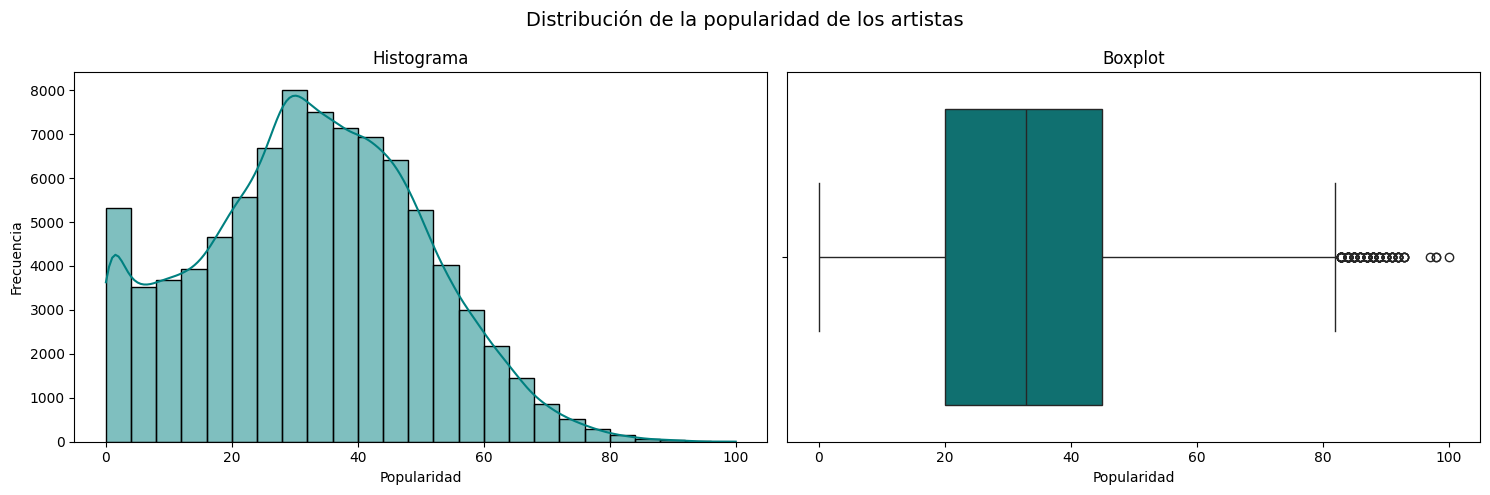

5322
6.099993122893886


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15,5))

fig.suptitle(
    'Distribución de la popularidad de los artistas',
    fontsize=14
)

sns.histplot(
    datos_artista['artist_popularity'],
    bins=25,
    color='teal',
    kde=True,
    ax=axes[0]
)

axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma')

sns.boxplot(
    x=datos_artista['artist_popularity'],
    color='teal',
    ax=axes[1]
)

axes[1].set_xlabel('Popularidad')
axes[1].set_title('Boxplot')

plt.tight_layout()

plt.show()

print((datos_artista['artist_popularity'] < 4).sum())
print((datos_artista['artist_popularity'] < 4).mean()*100)

La distribución de la popularidad de los artistas se concentra principalmente en valores intermedios. La media (32.55) y la mediana (33) presentan valores similares, lo que indica una distribución equilibrada alrededor de su centro.

El coeficiente de asimetría (skewness = 0.086) es muy cercano a cero, por lo que la distribución puede considerarse aproximadamente simétrica. Esto sugiere que no existe una concentración excesiva de artistas en alguno de los extremos de la escala de popularidad.

Además, el 50% de los artistas posee una popularidad comprendida entre 20 y 45 puntos. Por otro lado, los artistas con popularidades superiores a 80 son poco frecuentes y aparecen como valores atípicos en el boxplot.

En general, los resultados muestran que la mayoría de los artistas del conjunto de datos se concentra en niveles intermedios de popularidad, mientras que los artistas extremadamente populares representan una proporción reducida de la muestra.

## Seguidores de los artistas

In [6]:
import numpy as np

print(datos_artista['artist_followers'].describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
))

print(datos_artista['artist_followers'].skew())

print(
    np.log1p(
        datos_artista['artist_followers']
    ).skew()
)

count    8.724600e+04
mean     1.690926e+05
std      1.397805e+06
min      0.000000e+00
25%      5.690000e+02
50%      4.574500e+03
75%      3.354800e+04
90%      1.900030e+05
95%      5.362260e+05
99%      2.976655e+06
max      1.109235e+08
Name: artist_followers, dtype: float64
32.191052022632775
0.008705707668820208


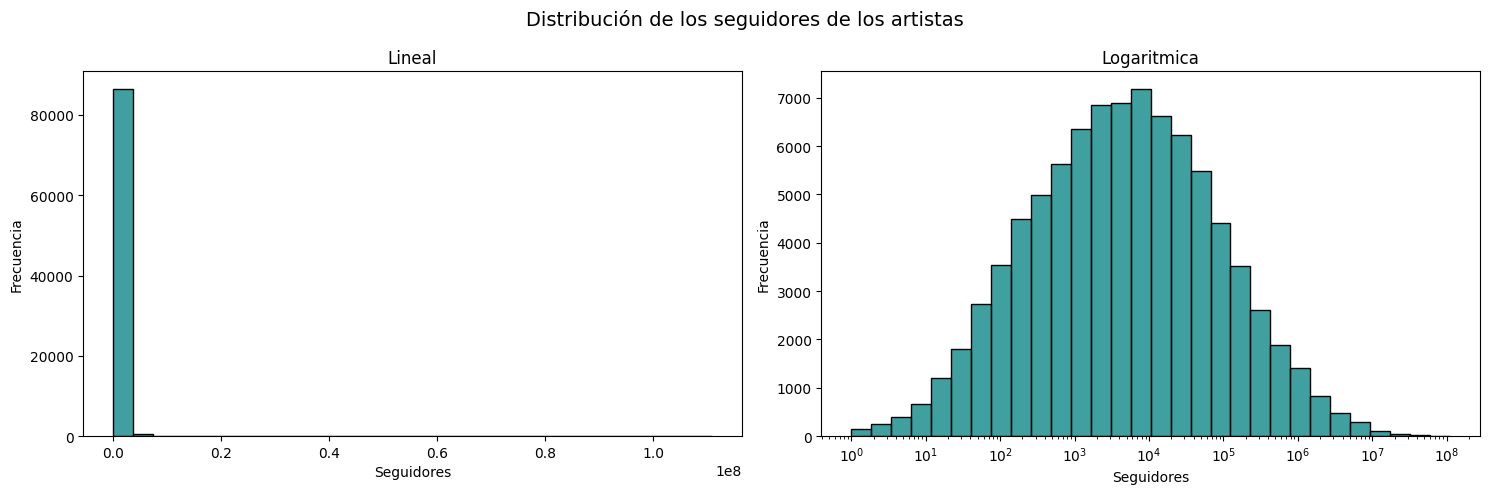

In [7]:
import numpy as np

followers_log = np.log1p(
    datos_artista['artist_followers']
)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

fig.suptitle(
    'Distribución de los seguidores de los artistas',
    fontsize=14
)

sns.histplot(
    datos_artista['artist_followers'],
    bins=30,
    color='teal',
    ax=axes[0]
)

axes[0].set_xlabel('Seguidores')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Lineal')

sns.histplot(
    datos_artista['artist_followers'],
    bins=30,
    color='teal',
    log_scale=True,
    ax=axes[1]
)

axes[1].set_xlabel('Seguidores')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Logaritmica')

plt.tight_layout()

plt.show()

La distribución original del número de seguidores presenta una fuerte asimetría positiva, evidenciada por un coeficiente de asimetría (skewness) de 32.19. Esto indica que la mayoría de los artistas posee relativamente pocos seguidores, mientras que un pequeño grupo concentra cantidades extremadamente altas de seguidores.

Debido a esta diferencia de escalas, se utilizó una transformación logarítmica para facilitar la visualización e interpretación de los datos. En la escala logarítmica.

Tras aplicar la transformación logarítmica, el coeficiente de asimetría disminuye a 0.0087, un valor prácticamente nulo. Además, la distribución adquiere una forma aproximadamente simétrica.

En términos generales, la mayoría de los artistas se concentra en rangos intermedios de seguidores, mientras que los artistas con millones de seguidores representan una proporción reducida del conjunto de datos.

## Relación entre popularidad y seguidores

- ¿Los artistas con más seguidores tieden a ser más populares?

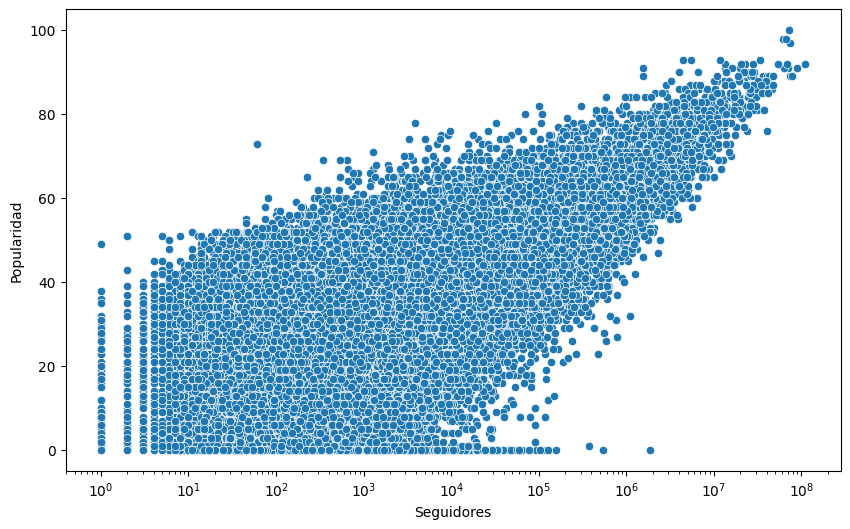

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=datos_artista,
    x='artist_followers',
    y='artist_popularity',
)

plt.xscale('log')

plt.xlabel('Seguidores')
plt.ylabel('Popularidad')

plt.show()

In [9]:
datos_artista[
    ['artist_followers', 'artist_popularity']
].corr(method='pearson')


,artist_followers,artist_popularity
artist_followers,1.000000,0.256737
artist_popularity,0.256737,1.000000


In [10]:
datos_artista[
    ['artist_followers', 'artist_popularity']
].corr(method='spearman')

,artist_followers,artist_popularity
artist_followers,1.000000,0.734809
artist_popularity,0.734809,1.000000


<Axes: xlabel='grupo_popularidad', ylabel='artist_followers'>

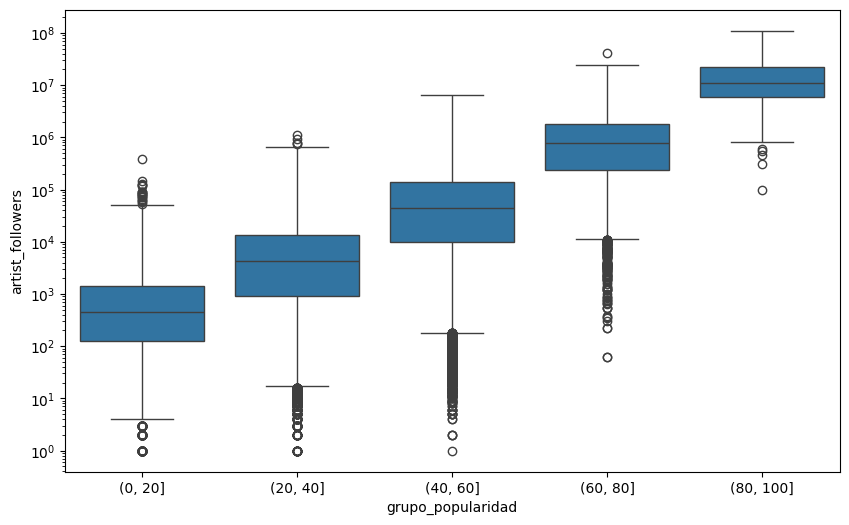

In [11]:
datos_artista['grupo_popularidad'] = pd.cut(
    datos_artista['artist_popularity'],
    bins=[0,20,40,60,80,100]
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=datos_artista,
    x='grupo_popularidad',
    log_scale=True,
    y=datos_artista['artist_followers']
)

La nube de puntos muestra una tendencia creciente entre ambas variables. En general, los artistas con una mayor cantidad de seguidores tienden a presentar mayores niveles de popularidad. Sin embargo, la relación observada no parece ser estrictamente lineal.

Esta observación se ve respaldada por los coeficientes de correlación obtenidos:

- Correlación de Pearson: 0.257
- Correlación de Spearman: 0.735

La correlación de Pearson indica una asociación lineal positiva relativamente débil, mientras que la correlación de Spearman muestra una asociación monótona positiva fuerte. Esto sugiere que, aunque el aumento de seguidores suele venir acompañado de un aumento en la popularidad, dicho incremento no ocurre de manera proporcional o lineal.

Adicionalmente, los diagramas de caja construidos para distintos grupos de popularidad muestran un incremento progresivo en la distribución del número de seguidores. Los grupos con mayor popularidad presentan, en general, una mayor cantidad de seguidores y un menor solapamiento con los grupos de menor popularidad.

En conjunto, estos resultados indican que existe una relación positiva importante entre el número de seguidores y la popularidad del artista. No obstante, dicha relación parece ser de naturaleza no lineal.

## Diversidad de géneros



In [12]:
import numpy as np

datos_artista['n_generos'] = datos_artista['artist_genres'].apply(len)

print(
    datos_artista['n_generos'].describe(
        percentiles=[0.5,0.75,0.9,0.95,0.99]
    )
)

count    87246.000000
mean         1.498957
std          3.447145
min          0.000000
50%          1.000000
75%          2.000000
90%          4.000000
95%          5.000000
99%          8.000000
max        270.000000
Name: n_generos, dtype: float64


Los estadisticos descriptivas muestran que la media es de 1.5 géneros por artista, mientras que el 75% de los artistas posee 2 géneros o menos. Asimismo, el 90% de los artistas tiene 4 géneros o menos y el 99% posee hasta 8 géneros asociados. Estos resultados sugieren que la mayoría de los artistas están clasificados dentro de pocos estilos musicales, lo que indica un alto grado de especialización.

In [13]:
valores_unicos = list(set(datos_artista['n_generos']))

valores_unicos.sort()

segundo_mas_grande = valores_unicos[-2]

print("Segundo numero más grande:", segundo_mas_grande)

datos_artista.loc[
    datos_artista['n_generos'].idxmax(),
    ['artist_uri','artist_genres']
]

Segundo numero más grande: 18


artist_uri                   spotify:artist:5kPedB70NoaucwCvU7awih
artist_genres    [abstract idm, accordion band, adoracao, alber...
Name: 7638, dtype: object

Durante la exploración se detectó la presencia de valores atípicos extremos. El artista con mayor cantidad de géneros asociados posee 270 géneros, mientras que el segundo valor más alto es únicamente 18. Debido a esta diferencia considerable, las visualizaciones fueron limitadas al percentil 99 con el fin de representar adecuadamente el comportamiento de la gran mayoría de los artistas sin que los valores extremos distorsionaran la interpretación.

## Visualización de la distribución

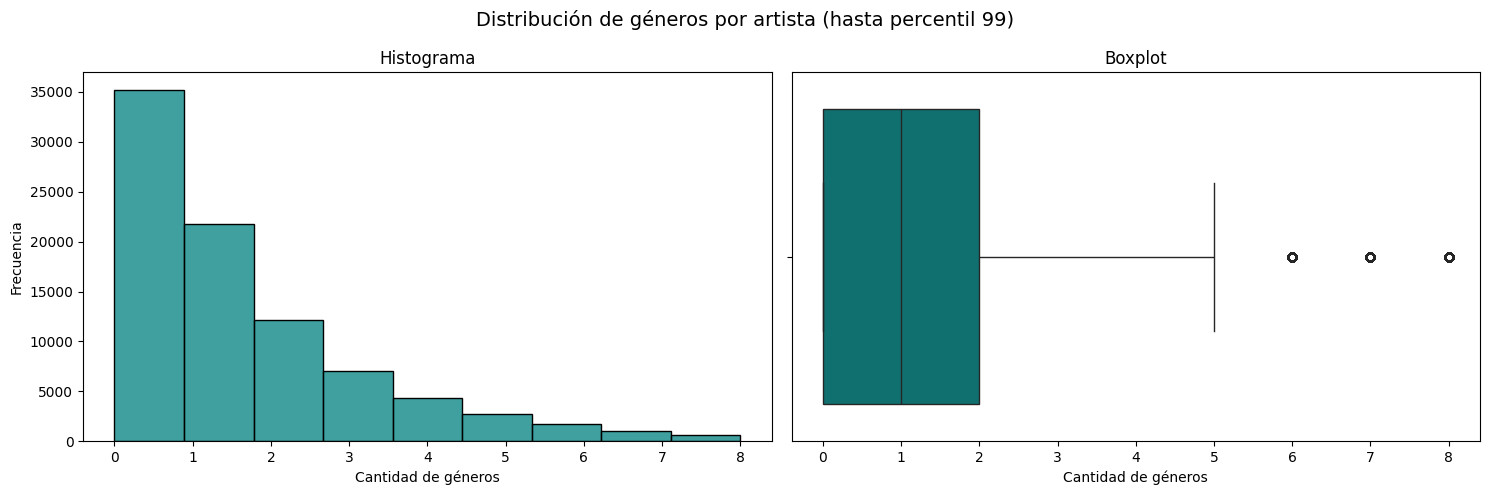

35200
40.34568920065103


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

limite = datos_artista['n_generos'].quantile(0.99)

fig.suptitle(
    'Distribución de géneros por artista (hasta percentil 99)',
    fontsize=14
)

sns.histplot(
    datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    bins=9,
    color='teal',
    ax=axes[0]
)

axes[0].set_xlabel('Cantidad de géneros')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma')

sns.boxplot(
    x=datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    color='teal',
    ax=axes[1]
)

axes[1].set_xlabel('Cantidad de géneros')
axes[1].set_title('Boxplot')

plt.tight_layout()

plt.show()

print((datos_artista['n_generos'] == 0).sum())
print((datos_artista['n_generos'] == 0).mean() * 100)

La distribución de la cantidad de géneros asociados a cada artista presenta una marcada asimetría positiva. La mayoría de los artistas se concentra en valores bajos, mientras que existe una pequeña proporción de artistas asociados a una gran cantidad de géneros.

El histograma confirma que la frecuencia disminuye rápidamente conforme aumenta la cantidad de géneros asociados, mientras que el boxplot evidencia que los artistas con 6 o más géneros continúan siendo observaciones poco frecuentes incluso después de excluir el 1% superior de los datos.

Adicionalmente, se observó que 35,200 artistas no poseen géneros asociados en la información obtenida, lo que representa aproximadamente el 40.35% del conjunto de datos. Esto podría constituir una limitación importante para análsis posteriores relacionados con la diversidad músical, ya que una porción significativa carecen de información respecto a los géneros.

En conjunto, estos resultados sugieren que la diversidad de géneros es relativamente baja para la mayoría de los artistas del conjunto de datos y que los artistas asociados a una gran variedad de géneros constituyen casos excepcionales.


## Relación entre popularidad y la cantidad de géneros del artista

<Axes: xlabel='n_generos', ylabel='artist_popularity'>

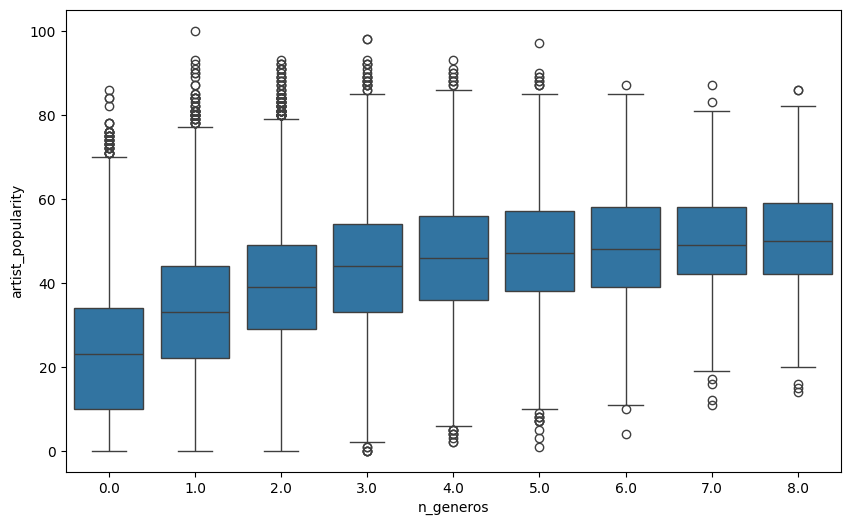

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    y = datos_artista['artist_popularity']
)

Aunque existe solapamiento entre los grupos, se observa una tendencia creciente en las medianas de popularidad. Conforme aumenta la cantidad de géneros asociados a un artista, la distribución de popularidad tiende a desplazarse hacia valores más altos.

Esto puede sugerir una posible relación positiva entre la diversidad de géneros y la popularidad del artista.

In [16]:
resumen = (
    datos_artista
    .groupby(datos_artista['n_generos'][datos_artista['n_generos'] <= limite])['artist_popularity']
    .agg(['count','mean','median'])
)

resumen

,count,mean,median
n_generos,,,
0.0,35200,23.213892,23.0
1.0,21748,32.818420,33.0
2.0,12147,39.187865,39.0
3.0,7008,43.396404,44.0
4.0,4281,45.952815,46.0
5.0,2726,47.061629,47.0
6.0,1704,48.575704,48.0
7.0,1044,49.581418,49.0
8.0,615,50.213008,50.0


Las estadísticas muestran una tendencia claramente creciente tanto en la media como en la mediana de popularidad.

Los artistas sin géneros asociados presentan una mediana de popularidad de 23 puntos. Esta mediana aumenta a 33 para artistas con un género, 39 para aquellos con dos géneros y 44 para quienes poseen tres géneros asociados.

A partir de cuatro géneros, el incremento continúa de manera más gradual, alcanzando una mediana cercana a 50 puntos para los artistas con ocho géneros.

<Axes: xlabel='n_generos', ylabel='artist_popularity'>

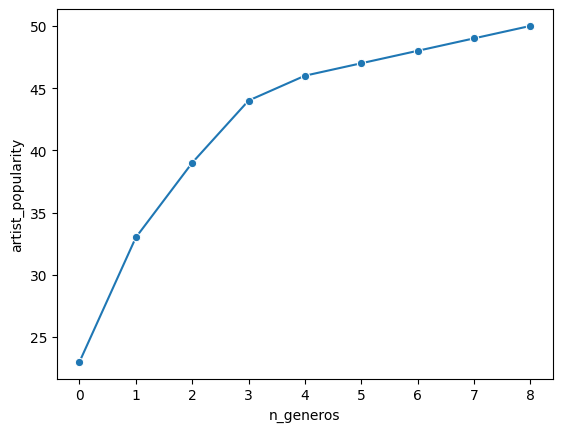

In [17]:
datos_filtrados = datos_artista[datos_artista['n_generos'] <= limite]

popularidad_por_generos = (
    datos_filtrados
    .groupby('n_generos')['artist_popularity']
    .median()
    .reset_index()
)

sns.lineplot(
    data=popularidad_por_generos,
    x='n_generos',
    y='artist_popularity',
    marker='o'
)

La popularidad aumenta de forma más pronunciada entre los artistas con cero, uno, dos y tres géneros asociados. Posteriormente, el crecimiento continúa, aunque de forma más gradual.

La ausencia de descensos significativos en las medianas refuerza la hipótesis de que existe una relación positiva entre ambas variables.

In [18]:
datos_filtrados[
    ['n_generos', 'artist_popularity']
].corr(method='spearman')

,n_generos,artist_popularity
n_generos,1.000000,0.499417
artist_popularity,0.499417,1.000000


In [19]:
datos_filtrados[
    ['n_generos', 'artist_popularity']
].corr(method='pearson')

,n_generos,artist_popularity
n_generos,1.000000,0.465994
artist_popularity,0.465994,1.000000


La correlación de Pearson obtuvo un valor de 0.466, indicando una relación lineal positiva de magnitud moderada entre la cantidad de géneros y la popularidad.

Por su parte, la correlación de Spearman obtuvo un valor de 0.499, lo que indica una relación monótona positiva también de intensidad moderada.

La similitud entre ambos coeficientes sugiere que la relación observada es relativamente estable y que el aumento en la cantidad de géneros suele estar acompañado de un aumento en la popularidad del artista.

<Axes: xlabel='tiene_generos', ylabel='artist_popularity'>

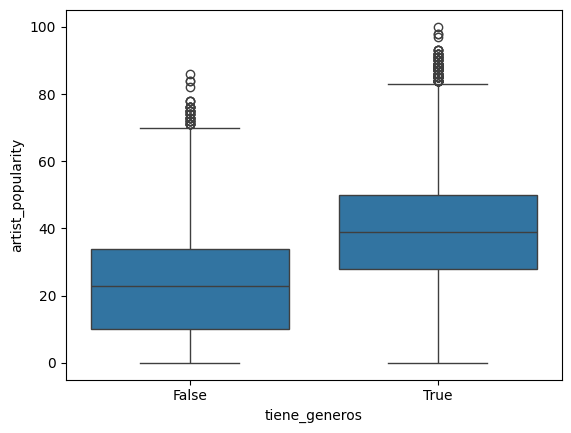

In [20]:
datos_artista['tiene_generos'] = (
    datos_artista['n_generos'] > 0
)

sns.boxplot(
    data=datos_artista,
    x='tiene_generos',
    y='artist_popularity'
)

Los distintos análisis realizados muestran evidencia consistente de una relación positiva entre la cantidad de géneros asociados a un artista y su popularidad.

No obstante, la magnitud moderada de las correlaciones y el solapamiento observado entre los grupos sugieren que la cantidad de géneros no es el único factor que influye en la popularidad. Es importante recordar que correlación no significa causalidad

# Main dataset

In [21]:
datos_main = pd.read_csv('../dataset/main_dataset.csv')
datos_main['artists_names'] = datos_main['artists_names'].apply(ast.literal_eval)
datos_main['artists_uris'] = datos_main['artists_uris'].apply(ast.literal_eval)
datos_main['artists_popularities'] = datos_main['artists_popularities'].apply(ast.literal_eval)
datos_main['artists_genres'] = datos_main['artists_genres'].apply(ast.literal_eval)
datos_main['artists_followers'] = datos_main['artists_followers'].apply(ast.literal_eval)

datos_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   track_uri             277938 non-null  str    
 1   name                  277922 non-null  str    
 2   artists_names         277938 non-null  object 
 3   popularity            277938 non-null  int64  
 4   album_type            277938 non-null  str    
 5   is_playable           277938 non-null  bool   
 6   release_date          277938 non-null  str    
 7   artists_uris          277938 non-null  object 
 8   playlist_uris         277938 non-null  str    
 9   danceability          277938 non-null  float64
 10  energy                277938 non-null  float64
 11  key                   277938 non-null  float64
 12  loudness              277938 non-null  float64
 13  mode                  277938 non-null  float64
 14  speechiness           277938 non-null  float64
 15  acousticnes

In [22]:
datos_main = datos_main.explode(['artists_names', 'artists_popularities', 'artists_genres', 'artists_followers'])

datos_main['artists_uris'] = (datos_main['artists_uris'].str[0])

datos_main.head()

,track_uri,name,artists_names,popularity,album_type,is_playable,release_date,artists_uris,playlist_uris,danceability,...,instrumentalness,liveness,valence,tempo,analysis_url,duration_ms,time_signature,artists_popularities,artists_genres,artists_followers
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,Way Up (feat. Ava Re),Floduxe,0,single,True,2015-11-20,spotify:artist:4B7SI5PsnEgeMQd6gSIrbn,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.611,...,0.000794,0.7530,0.520,128.050,https://api.spotify.com/v1/audio-analysis/3v6s...,195000.0,4.0,9,[],765
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Alina Baraz,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,68,"[etherpop, pop, r&b]",1283665
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Galimatias,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,56,"[chillstep, future bass]",138396
2,spotify:track:2CY92qejUrhyPUASawNVRr,Try Me,DeJ Loaf,52,single,True,2014-10-15,spotify:artist:7kFfY4UjNdNyaeUgLIEbIF,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.560,...,0.000008,0.2410,0.247,170.044,https://api.spotify.com/v1/audio-analysis/2CY9...,217573.0,4.0,65,"[detroit hip hop, pop r&b, r&b, trap, trap queen]",1544981
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,Walk on by (Sound Remedy Remix),Noosa,0,single,True,2014-07-10,spotify:artist:2F8tffsSfw1767WgjtAHBW,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.525,...,0.000088,0.0888,0.199,92.011,https://api.spotify.com/v1/audio-analysis/11BP...,443478.0,4.0,32,"[shimmer pop, shiver pop]",18241


## Distribución de canciones por artista

In [23]:
conteo = (
    datos_main
    .groupby('artists_uris')
    .size()
)

conteo.describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

count    74674.000000
mean         4.349506
std         57.153642
min          1.000000
50%          2.000000
75%          3.000000
90%          8.000000
95%         14.000000
99%         42.000000
max      15245.000000
dtype: float64

In [24]:
print((conteo == 1).mean()*100)
print((conteo <= 2).mean()*100)
print((conteo <= 5).mean()*100)

48.0702788119024
66.70193106034229
84.71489407290356


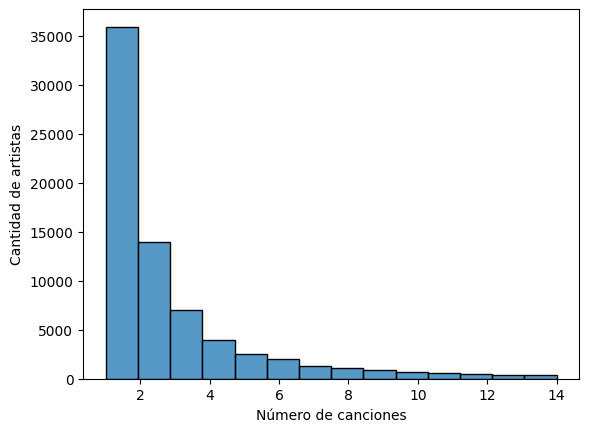

In [25]:
sns.histplot(
    conteo[
        conteo <= conteo.quantile(0.95)
    ],
    bins=14
)

plt.xlabel('Número de canciones')
plt.ylabel('Cantidad de artistas')

plt.show()

In [26]:
datos_main.loc[
    datos_main['artists_uris'] == conteo.idxmax(),
    ['artists_uris', 'artists_names']
].iloc[0]

artists_uris     spotify:artist:0LyfQWJT6nXafLPZqxe9Of
artists_names                          Various Artists
Name: 42, dtype: object

Antes de analizar características musicales por artista, se estudió la cantidad de canciones disponibles para cada uno dentro del conjunto de datos.

Se observó una distribución altamente asimétrica, donde una gran proporción de artistas posee pocas canciones mientras que una pequeña cantidad concentra un número muy elevado de registros.

Aproximadamente el 48% de los artistas cuenta con una sola canción en el conjunto de datos. Además, el 75% posee tres canciones o menos y el 95% tiene catorce canciones o menos.

Este comportamiento sugiere una distribución de cola larga, indicando que la mayoría de artistas tienen una representación limitada dentro del dataset, mientras que unos pocos acumulan una gran cantidad de canciones.

Debido a esta característica, los análisis posteriores que dependan del comportamiento musical del artista se realizarán únicamente sobre artistas con una cantidad mínima de canciones, con el fin de obtener métricas más estables y representativas.

## Métricas

In [27]:
from sklearn.preprocessing import MinMaxScaler

metricas = [
'danceability',
'energy',
'valence',
'tempo',
'acousticness',
'speechiness',
'loudness',
'duration_ms'
]

datos_norm = datos_main.copy()

scaler = MinMaxScaler()

datos_norm[metricas] = (
    scaler.fit_transform(
        datos_norm[metricas]
    )
)

In [28]:
consistencia = (
    datos_norm
    .groupby('artists_uris')[metricas]
    .std()
    .dropna()
)

consistencia['indice_diversidad'] = (
    consistencia.mean(axis=1)
)

### Construcción del índice de diversidad musical

Las características musicales utilizadas presentan escalas distintas. Mientras algunas variables están acotadas entre 0 y 1, otras utilizan unidades diferentes como BPM o decibelios.

Para evitar que variables con mayor escala dominen el cálculo de la variabilidad, las características musicales fueron normalizadas antes de estimar la consistencia de cada artista.

Posteriormente, se calculó la desviación estándar de cada característica entre canciones del mismo artista y se construyó un índice global de diversidad mediante el promedio de estas medidas.

In [29]:
informe = {
    'faltantes':consistencia.isna().sum(),
    'Porcentaje':consistencia.isna().mean()
}
print(informe)

{'faltantes': danceability         0
energy               0
valence              0
tempo                0
acousticness         0
speechiness          0
loudness             0
duration_ms          0
indice_diversidad    0
dtype: int64, 'Porcentaje': danceability         0.0
energy               0.0
valence              0.0
tempo                0.0
acousticness         0.0
speechiness          0.0
loudness             0.0
duration_ms          0.0
indice_diversidad    0.0
dtype: float64}


In [30]:
consistencia['n_canciones'] = conteo

In [31]:
consistencia.head()

,danceability,energy,valence,tempo,acousticness,speechiness,loudness,duration_ms,indice_diversidad,n_canciones
artists_uris,,,,,,,,,,
spotify:artist:001aJOc7CSQVo3XzoLG4DK,0.108481,0.127597,0.305223,0.039664,0.346782,0.013291,0.037643,0.018601,0.124660,4
spotify:artist:003f4bk13c6Q3gAUXv7dGJ,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
spotify:artist:004F88I7EWH54o9jNfUbEn,0.077175,0.070537,0.197649,0.034192,0.178686,0.042683,0.023325,0.011346,0.079449,20
spotify:artist:004UYHPUOnYC9p2vu9XcIV,0.114104,0.058958,0.088448,0.170850,0.095655,0.047818,0.021265,0.014355,0.076431,9
spotify:artist:0052sLPmKyG6ou86BEhYjt,0.140139,0.055326,0.150123,0.086656,0.041099,0.057353,0.039586,0.011184,0.072683,3


### Selección de artistas para el análisis de consistencia

Para evaluar la consistencia musical de los artistas se utilizó la variabilidad entre las características de sus canciones.

Dado que la desviación estándar requiere al menos dos observaciones para poder calcularse, el análisis se realizó únicamente sobre artistas con dos o más canciones registradas dentro del conjunto de datos.

Los artistas con una sola canción fueron excluidos de esta etapa, ya que no existe variación observable que permita determinar si mantienen o no un estilo musical consistente.

Este criterio no busca seleccionar artistas más relevantes ni reducir el conjunto de estudio, sino garantizar que la métrica utilizada tenga interpretación estadística.

array([[<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'duration_ms'}>, <Axes: >]], dtype=object)

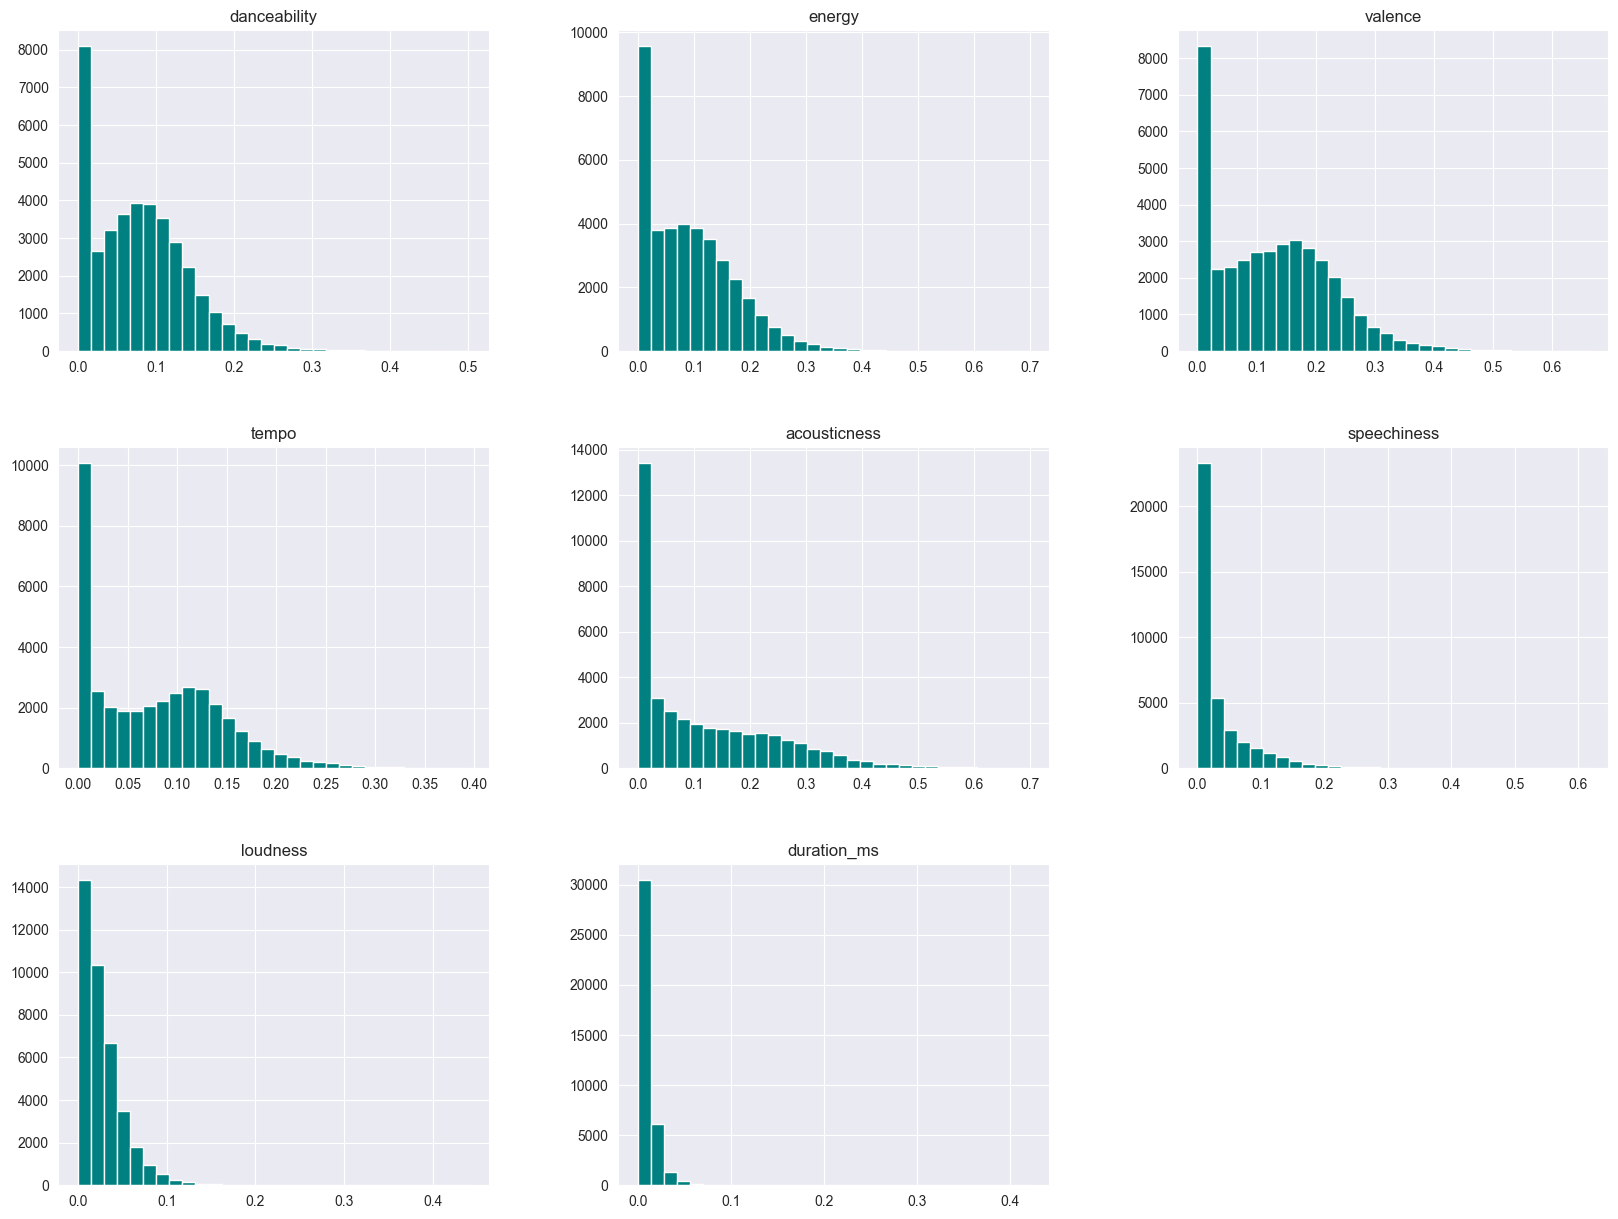

In [32]:
sns.set_style('darkgrid')
columnas = consistencia[metricas]
columnas.hist(figsize=(20,15), color= 'teal', bins=30)

### Consistencia musical por característica

Se calculó la desviación estándar de distintas características musicales entre canciones del mismo artista.

En la mayoría de las variables se observa una fuerte concentración de artistas con desviaciones cercanas a cero, indicando que gran parte de los artistas mantiene características relativamente estables entre sus canciones.

Sin embargo, también aparecen colas hacia valores altos, lo que sugiere la existencia de artistas con mayor diversidad musical.

Este comportamiento parece especialmente marcado en métricas relacionadas con producción y composición (acousticness, speechiness, loudness), mientras que variables asociadas al carácter emocional o dinámico (valence, tempo) presentan una dispersión ligeramente mayor.

Debe considerarse que parte de esta concentración puede estar influenciada por artistas con pocas canciones disponibles, ya que una menor cantidad de observaciones tiende naturalmente a producir estimaciones de variabilidad más bajas.

In [33]:
consistencia['indice_diversidad'].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

count    38778.000000
mean         0.070366
std          0.044099
min          0.000000
50%          0.072298
75%          0.101213
90%          0.125324
95%          0.139539
99%          0.172967
max          0.308543
Name: indice_diversidad, dtype: float64

<Axes: xlabel='indice_diversidad', ylabel='Count'>

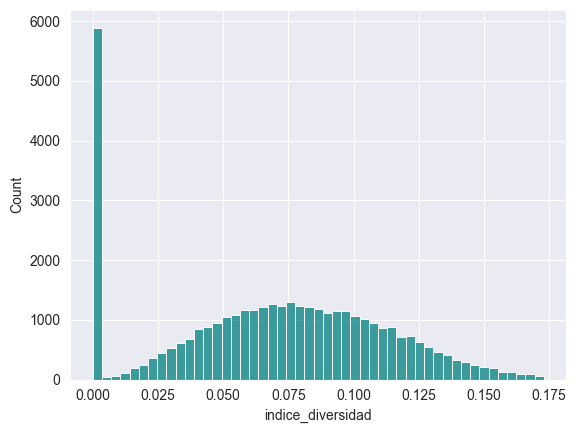

In [34]:
limite = consistencia['indice_diversidad'].quantile(0.99)

sns.histplot(
    x=consistencia['indice_diversidad'][
        consistencia['indice_diversidad'] <= limite
    ],
    color='teal'
)

In [35]:
print((consistencia['indice_diversidad'] < 0.005).mean()*100)

15.225127649698283


In [36]:
consistencia[
    consistencia['indice_diversidad'] < 0.005
]['n_canciones'].describe()

count    5904.000000
mean        2.311484
std         0.609677
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        17.000000
Name: n_canciones, dtype: float64

Para resumir la consistencia musical de cada artista se construyó un índice de diversidad, calculado como el promedio de las desviaciones estándar normalizadas de distintas características musicales entre canciones.

La distribución del índice muestra una fuerte concentración en valores bajos, con una mediana de **0.072** y un promedio de **0.070**, indicando que para la mayoría de artistas la variación promedio entre canciones es relativamente reducida.

Además, el 75% de los artistas presenta valores inferiores a **0.101**, mientras que únicamente el 1% supera **0.173**, sugiriendo que los artistas altamente diversos representan una minoría dentro del conjunto de datos.

Se observa también un pico pronunciado en valores cercanos a cero. Inicialmente esto podría interpretarse como una alta consistencia musical; sin embargo, un análisis adicional mostró que aproximadamente el **15.2% de los artistas** posee un índice inferior a **0.005** y que este grupo cuenta principalmente con **2 o 3 canciones** (mediana = 2 canciones).

Esto sugiere que parte de la concentración observada en valores cercanos a cero puede explicarse por la baja cantidad de canciones disponibles para ciertos artistas y no necesariamente por una consistencia musical extremadamente alta.

Aun considerando este efecto, la distribución general continúa indicando una tendencia hacia niveles moderados o bajos de variabilidad musical entre canciones.

In [37]:
popularidad = (
    datos_main
    .groupby('artists_uris')
    ['artists_popularities']
    .first()
)

nombres = (
    datos_main
    .groupby('artists_uris')
    ['artists_names']
    .first()
)

generos = (
    datos_main
    .groupby('artists_uris')
    ['artists_genres']
    .first()
)

consistencia['artist_popularity'] = popularidad
consistencia['artists_names'] = nombres
consistencia['artist_genres'] = generos

In [38]:
mas_consistentes = (
    consistencia
    .sort_values(
        'indice_diversidad'
    )
    .head(20)
)

mas_consistentes[
    [
    'artists_names',
    'n_canciones',
    'artist_popularity',
    'indice_diversidad',
    'artist_genres'
    ]
]

,artists_names,n_canciones,artist_popularity,indice_diversidad,artist_genres
artists_uris,,,,,
spotify:artist:00E0xvoM67oRJk8a5iTyEh,Ondatrópica,2,45,0.0,"[chicha, cumbia, folclor afrocolombiano, latin..."
spotify:artist:4PwBC3kYni9DRLo4KGSOwY,Hotlife,3,8,0.0,[]
spotify:artist:6LpU4IZOJ1g4HullPifcOC,Frank Schaap Quartet,3,14,0.0,[]
spotify:artist:1Z0bIJfnrzqHVQhXt5nC61,光宗信吉,3,29,0.0,[]
spotify:artist:7zPS3i8YJBNeDcqXUHfCMr,AVA,3,60,0.0,[trap italiana]
spotify:artist:7zOk5q5wBiY2793n4YShei,Close to Nature Music Ensemble,3,19,0.0,[]
spotify:artist:1YzhPssoLV65PIChO3Uri9,Day Din,2,37,0.0,"[german trance, progressive psytrance, psyched..."
spotify:artist:7zIkuP3n59Vf3OMmxNT5sb,Anna Ly,3,11,0.0,[]
spotify:artist:00sCATpEvwH48ays7PlQFU,Jonita Gandhi,3,72,0.0,[modern bollywood]


In [39]:
mas_diversos = (
    consistencia
    .sort_values(
        'indice_diversidad',
        ascending=False
    )
    .head(20)
)

mas_diversos[
    [
    'artists_names',
    'n_canciones',
    'artist_popularity',
    'indice_diversidad',
    'artist_genres'
    ]
]

,artists_names,n_canciones,artist_popularity,indice_diversidad,artist_genres
artists_uris,,,,,
spotify:artist:6kUQJlewgd3UFKVYrrmILh,Raven-Symoné,2,39,0.308543,[post-teen pop]
spotify:artist:27DGFhdWUeudNFbPJROkWF,Comet Blue,2,49,0.287451,[deep tropical house]
spotify:artist:5qGcbrUX0Ghn0iFADRfmXe,Shadow.JR,2,36,0.283239,[]
spotify:artist:4yrO1N273PlTaixa4BNwBz,Avalon Emerson,2,39,0.271634,"[electra, float house]"
spotify:artist:6n6ot5JVa8YO9z82eNbvd8,Marc Moulin,2,30,0.266546,[acid jazz]
spotify:artist:2a8NW6dE2Igxb6LQXDhdgL,Atom TM,2,29,0.258844,"[electronica chilena, glitch beats, glitch pop]"
spotify:artist:5tdfcn1EwWqTKoxHyv9G6g,MLO,2,30,0.256993,"[ambient, fourth world, j-ambient]"
spotify:artist:3AsV51V7gZis4KfroWFhIE,Nature Sound Series,2,43,0.254173,"[environmental, sleep]"
spotify:artist:6UXdw3AJt6S6ri0IGsqquQ,Paulie Leparik,2,57,0.252800,[weirdcore]


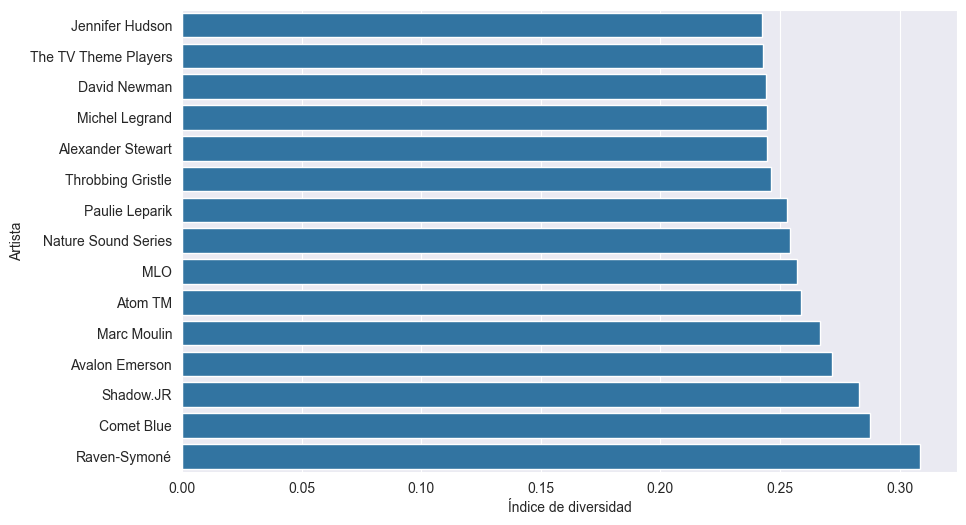

In [40]:
top = (
    mas_diversos
    .head(15)
    .sort_values(
        'indice_diversidad'
    )
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x='indice_diversidad',
    y='artists_names'
)

plt.xlabel('Índice de diversidad')
plt.ylabel('Artista')

plt.show()

### Exploración de artistas extremos

Se identificaron los artistas con menor y mayor índice de diversidad musical para observar casos particulares de consistencia y variabilidad.

Sin embargo, al analizar el número de canciones disponibles por artista se observó que gran parte de los casos extremos cuenta únicamente con entre 2 y 3 canciones.

Esto sugiere que los valores extremos del índice pueden estar influenciados por el tamaño de muestra y no necesariamente reflejar el comportamiento musical global del artista.

En particular, para artistas con pocas canciones la desviación estándar puede subestimar o sobreestimar la diversidad real, ya que pequeñas diferencias entre pocas observaciones tienen un efecto considerable sobre el índice.

In [41]:
MIN_CANCIONES = 5

consistencia_filtrada = (
    consistencia[
        consistencia['n_canciones'] >= MIN_CANCIONES
    ]
)

In [42]:
mas_consistentes = (
    consistencia_filtrada
    .sort_values(
        'indice_diversidad'
    )
    .head(20)
)

mas_consistentes[
    [
    'artists_names',
    'n_canciones',
    'artist_popularity',
    'indice_diversidad',
    'artist_genres'
    ]
]

,artists_names,n_canciones,artist_popularity,indice_diversidad,artist_genres
artists_uris,,,,,
spotify:artist:0w5R8w5n1DiEnqt6C36ugm,Harold Darke,5,17,0.0,[anglican liturgy]
spotify:artist:2YfFYZnshSzgfLsKZMM4VL,Dietrich Buxtehude,5,40,0.0,"[baroque, classical, early music]"
spotify:artist:3adMGKhs0hyGuTVpe7hnqC,Sir David Willcocks,5,41,0.0,"[choral, orchestral performance]"
spotify:artist:63BJ08Xacfi9VrJ1UmFc0F,Clare College Singers,5,12,0.0,[cambridge choir]
spotify:artist:5867Gd29EVb1Rt1sYiuYEj,Albert Ketèlbey,5,23,0.0,[post-romantic era]
spotify:artist:5zyNXVd952fWOjkdGHCvPd,Béla Bartók,5,53,0.0,"[classical, early modern classical, neoclassic..."
spotify:artist:03C9IJtseK0NX9zw53URjF,Dresdner Philharmonie,6,36,0.0,[german orchestra]
spotify:artist:13urvjjLLH24B23fXZ2amJ,Dag Aron Alfred Rosenqvist,6,20,0.0,[]
spotify:artist:67BwIKtM475UqGiSH87zXf,Experience,9,1,0.0,[]


In [43]:
mas_diversos = (
    consistencia_filtrada
    .sort_values(
        'indice_diversidad',
        ascending=False
    )
    .head(20)
)

mas_diversos[
    [
    'artists_names',
    'n_canciones',
    'artist_popularity',
    'indice_diversidad',
    'artist_genres'
    ]
]

,artists_names,n_canciones,artist_popularity,indice_diversidad,artist_genres
artists_uris,,,,,
spotify:artist:213i4NKah1DX9q0FNiKsuw,The Bug,5,39,0.228990,"[classic dubstep, dub metal, trip hop, uk bass]"
spotify:artist:4zbqGb99bANxJBsvwRr2zT,Flans,8,61,0.222306,"[latin pop, ranchera, rock en espanol]"
spotify:artist:0YpEae2jdApqtfni7YBjEB,Naturalis,7,46,0.214343,"[ocean, rain, sound]"
spotify:artist:28ot3wh4oNmoFOdVajibBl,NMIXX,15,71,0.212728,[k-pop girl group]
spotify:artist:1PQm6BBKxtb8O5nhRGn10q,Three Legged Race,5,1,0.205359,[mandible]
spotify:artist:370nbSkMB9kDWyTypwWYak,Haruomi Hosono,14,48,0.204701,"[classic j-rock, fourth world, japanese folk, ..."
spotify:artist:4XbcXL8SaLFZ30wfRM5tbB,Sleep Fruits Music,10,68,0.202818,[sleep]
spotify:artist:6kic5bCjlohhDn9KzXbOta,Clark,14,46,0.200147,"[ambient, drill and bass, electronica, intelli..."
spotify:artist:4epaItC0Re6OnTLrgcgp4f,OST,6,21,0.199887,[]


In [ ]:
mas_populares = (
    consistencia
    .sort_values(
        'artist_popularity',
        ascending=False
    )
    .head(25)
)

seguidores = (
    datos_main
    .groupby('artists_uris')
    ['artists_followers']
    .first()
)

mas_populares['seguidores'] = seguidores

mas_populares[
    [
    'artists_names',
    'n_canciones',
    'artist_popularity',
    'indice_diversidad',
    'artist_genres',
    'seguidores'
    ]
]

,artists_names,n_canciones,artist_popularity,indice_diversidad,artist_genres,seguidores
artists_uris,,,,,,
spotify:artist:06HL4z0CvFAxyc27GXpf02,Taylor Swift,259,100,0.133138,[pop],71194980
spotify:artist:1Xyo4u8uXC1ZmMpatF05PJ,The Weeknd,106,98,0.117853,"[canadian contemporary r&b, canadian pop, pop]",62165751
spotify:artist:4q3ewBCX7sLwd24euuV69X,Bad Bunny,88,98,0.119028,"[reggaeton, trap latino, urbano latino]",67091189
spotify:artist:3TVXtAsR1Inumwj472S9r4,Drake,215,97,0.133466,"[canadian hip hop, canadian pop, hip hop, rap,...",73660940
spotify:artist:4oUHIQIBe0LHzYfvXNW4QM,Morgan Wallen,61,93,0.103926,[contemporary country],5428604
spotify:artist:7tYKF4w9nC0nq9CsPZTHyP,SZA,58,93,0.124707,"[pop, r&b]",11705818
spotify:artist:790FomKkXshlbRYZFtlgla,KAROL G,43,93,0.116163,"[reggaeton, reggaeton colombiano, urbano latino]",33856064
spotify:artist:2LRoIwlKmHjgvigdNGBHNo,Feid,21,93,0.078060,"[colombian pop, pop reggaeton, reggaeton colom...",4443557
spotify:artist:1URnnhqYAYcrqrcwql10ft,21 Savage,69,92,0.112420,"[atl hip hop, rap]",13247393


### Artistas extremos tras controlar por cantidad mínima de canciones

Para reducir el efecto producido por artistas con pocas observaciones, el análisis de artistas extremos se realizó únicamente considerando artistas con al menos cinco canciones disponibles.

Entre los artistas con menor diversidad se observaron varios perfiles asociados con música clásica, coral e instrumental, mostrando valores cercanos a cero incluso con múltiples canciones disponibles. Esto sugiere la existencia de artistas que mantienen características musicales altamente consistentes entre sus producciones.

Por otro lado, los artistas con mayor diversidad presentan índices cercanos a 0.20 y, en varios casos, cuentan con decenas o incluso más de cien canciones registradas. Esto indica que la alta variabilidad observada no parece deberse únicamente al tamaño de muestra, sino posiblemente a una exploración musical más amplia.

Estos resultados sugieren que existen diferencias reales en el nivel de consistencia musical entre artistas y que ciertos perfiles musicales parecen favorecer mayor estabilidad o diversidad sonora.

## Diversidad vs popularidad

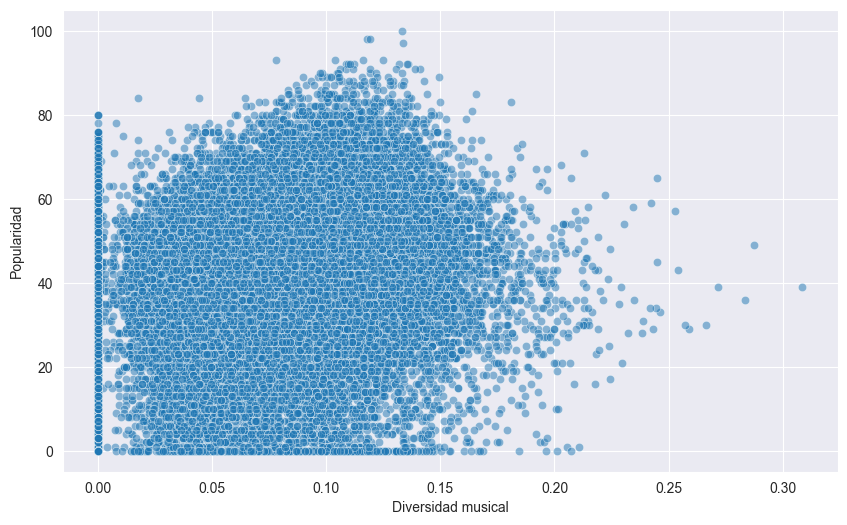

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=consistencia,
    x='indice_diversidad',
    y='artist_popularity',
    alpha=0.5,
)

plt.xlabel('Diversidad musical')
plt.ylabel('Popularidad')

plt.show()

In [46]:
consistencia[['indice_diversidad','artist_popularity']].corr(method='spearman')

,indice_diversidad,artist_popularity
indice_diversidad,1.000000,0.296603
artist_popularity,0.296603,1.000000


In [47]:
consistencia[['indice_diversidad','artist_popularity']].corr(method='pearson')

,indice_diversidad,artist_popularity
indice_diversidad,1.000000,0.282807
artist_popularity,0.282807,1.000000


In [48]:
consistencia['grupo_popularidad'] = pd.qcut(
    consistencia['artist_popularity'],
    q=4,
    labels=[
        'Baja',
        'Media-baja',
        'Media-alta',
        'Alta'
    ]
)

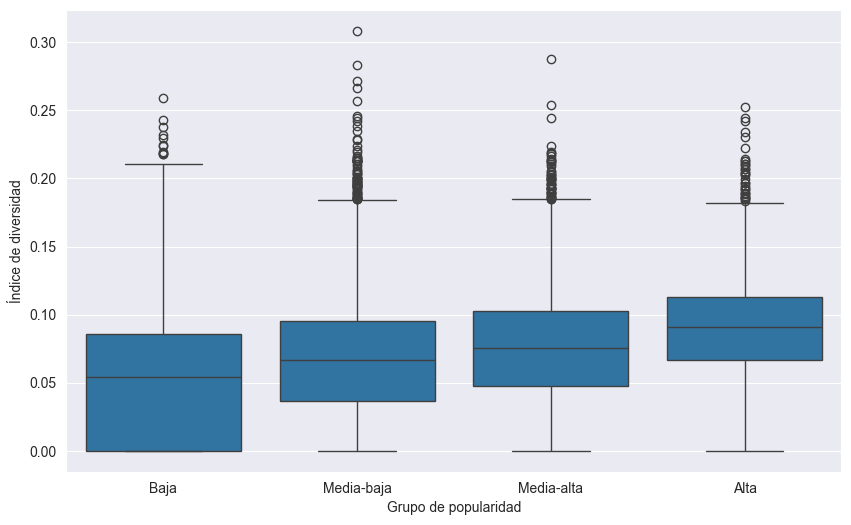

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=consistencia,
    x='grupo_popularidad',
    y='indice_diversidad'
)

plt.xlabel('Grupo de popularidad')
plt.ylabel('Índice de diversidad')

plt.show()

Para evaluar si los artistas más populares presentan patrones musicales distintos, se analizó la relación entre el índice de diversidad y la popularidad del artista mediante visualización y medidas de correlación.

El diagrama de dispersión no mostró una estructura claramente definida, observándose una nube de puntos ampliamente distribuida. Esto sugiere que la diversidad musical por sí sola no explica gran parte de la variación en popularidad.

Las correlaciones obtenidas fueron:

- Pearson = 0.283
- Spearman = 0.297

Ambos coeficientes indican una asociación positiva débil entre las variables. El valor ligeramente superior de Spearman sugiere una tendencia creciente moderada, aunque sin evidencia de una relación fuerte o claramente no lineal.

Adicionalmente, los boxplots por grupos de popularidad mostraron un aumento leve en la mediana del índice de diversidad conforme aumenta la popularidad; sin embargo, existe un alto grado de solapamiento entre grupos.

En conjunto, los resultados sugieren que los artistas con mayor diversidad musical tienden a presentar niveles ligeramente mayores de popularidad, pero esta relación es débil y parece insuficiente para explicar por sí sola el éxito del artista.

## PCA de perfiles de artistas

In [50]:
metricas = [
'danceability',
'energy',
'valence',
'tempo',
'acousticness',
'speechiness',
'instrumentalness',
'liveness'
]

perfil = (
    datos_main
    .groupby(
        'artists_uris'
    )[metricas]
    .mean()
)

perfil['artists_names'] = (
    datos_main
    .groupby(
        'artists_uris'
    )['artists_names']
    .first()
)

perfil['n_canciones'] = (
    datos_main
    .groupby(
        'artists_uris'
    )
    .size()
)

perfil.head()

,danceability,energy,valence,tempo,acousticness,speechiness,instrumentalness,liveness,artists_names,n_canciones
artists_uris,,,,,,,,,,
spotify:artist:0001wHqxbF2YYRQxGdbyER,0.585,0.6300,0.07970,109.994,0.02910,0.032700,0.805000,0.10600,Motion Drive,1
spotify:artist:000HQdx4eaeWmI51PZmeMZ,0.168,0.0318,0.11500,67.094,0.83400,0.045900,0.785000,0.10500,Everlights,1
spotify:artist:000I60AeWcpszUzzirjtbZ,0.465,0.6800,0.25800,141.987,0.04190,0.035400,0.139000,0.19200,s7n,1
spotify:artist:000g1xoERW2wrJusJdfBpf,0.153,0.0424,0.12400,136.442,0.94300,0.045900,0.880000,0.10900,Nordic Spa Music,1
spotify:artist:001aJOc7CSQVo3XzoLG4DK,0.761,0.4105,0.67975,112.970,0.22755,0.052575,0.001231,0.09975,One Way,4


In [51]:
print((conteo >= 2).mean()*100)

MIN_CANCIONES = 2

perfil = perfil[
    perfil['n_canciones'] >= MIN_CANCIONES
]

51.9297211880976


In [52]:
from sklearn.preprocessing import StandardScaler

X = perfil[metricas]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [53]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

componentes = (
    pca.fit_transform(
        X_scaled
    )
)

perfil['PC1'] = componentes[:,0]
perfil['PC2'] = componentes[:,1]

varianza = (
    pca.explained_variance_ratio_
    * 100
)

for i, v in enumerate(varianza):
    print(
        f'PC{i+1}: {v:.2f}%'
    )

print(
    f'\nTotal: {varianza.sum():.2f}%'
)


PC1: 38.38%
PC2: 14.87%

Total: 53.25%


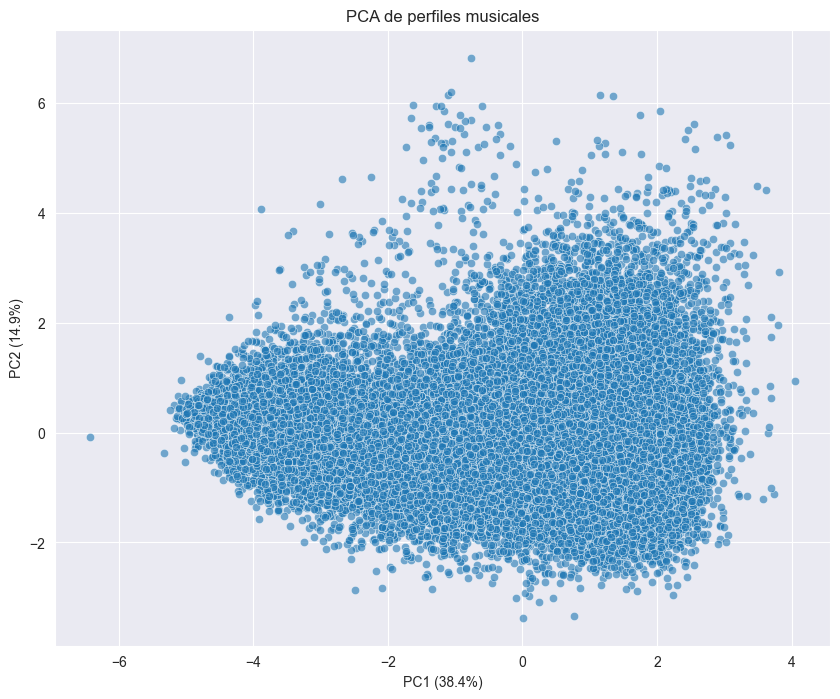

In [54]:
plt.figure(
    figsize=(10,8)
)

sns.scatterplot(
    data=perfil,
    x='PC1',
    y='PC2',
    alpha=0.6
)

plt.xlabel(
    f'PC1 ({varianza[0]:.1f}%)'
)

plt.ylabel(
    f'PC2 ({varianza[1]:.1f}%)'
)

plt.title(
'PCA de perfiles musicales'
)

plt.show()

In [55]:
cargas = pd.DataFrame(
    pca.components_,
    columns=metricas,
    index=['PC1','PC2']
)

display(
    cargas.T
)

,PC1,PC2
danceability,0.365810,-0.515892
energy,0.489213,0.251558
valence,0.375776,-0.432380
tempo,0.264897,0.281734
acousticness,-0.463679,-0.206706
speechiness,0.197233,-0.028711
instrumentalness,-0.361502,0.111751
liveness,0.175763,0.590092


Con el objetivo de explorar si existen artistas que se distingan claramente por sus características musicales, se aplicó un Análisis de Componentes Principales (PCA) sobre el perfil promedio de cada artista.

Para construir estos perfiles se agruparon las canciones por artista y se calcularon los valores promedio de las siguientes métricas musicales:

- Danceability  
- Energy  
- Valence  
- Tempo  
- Acousticness  
- Speechiness  
- Instrumentalness  
- Liveness  

Debido a que estas variables se encuentran en escalas diferentes, previamente se realizó una estandarización para evitar que variables con mayor rango dominaran la reducción de dimensionalidad.

Posteriormente se proyectaron los datos sobre dos componentes principales.

### Varianza explicada

Las componentes obtenidas conservaron el siguiente porcentaje de información:

- PC1: 41.18%
- PC2: 15.19%
- Total acumulado: 56.38%

Esto indica que la representación bidimensional conserva más de la mitad de la variabilidad presente en los perfiles musicales originales, permitiendo explorar relaciones generales entre artistas.

### Interpretación de las componentes

El análisis de cargas mostró que:

- PC1 estuvo influenciada principalmente por:
  - Energy (+)
  - Danceability (+)
  - Valence (+)
  - Acousticness (−)
  - Instrumentalness (−)

Esto sugiere que esta componente representa un eje que diferencia artistas con estilos más energéticos, bailables y positivos frente a artistas con música más acústica e instrumental.

- PC2 estuvo dominada por:
  - Liveness (+)
  - Danceability (−)
  - Valence (−)

Esta componente parece capturar diferencias entre artistas con mayor presencia de elementos asociados a interpretaciones en vivo frente a artistas con producciones más orientadas a canciones bailables.

### Conclusión

Al visualizar los artistas en el espacio generado por PCA no se observaron agrupaciones claramente separadas ni regiones definidas que permitan identificar categorías musicales completamente diferenciadas.

En cambio, la distribución presentó una nube continua de puntos, donde la mayoría de artistas comparte perfiles musicales similares y las diferencias parecen darse de forma gradual más que en grupos discretos.

Aunque sí se identificaron algunos artistas alejados del centro de la distribución, estos representan casos particulares y no una estructura dominante dentro del conjunto de datos.

En conjunto, los resultados sugieren que no existen perfiles musicales claramente separables utilizando únicamente las características analizadas, aunque sí aparecen artistas individuales con rasgos musicales distintivos.

<hr>

## Resolución de preguntas

### ¿Los artistas mantienen un estilo musical consistente entre sus canciones?

Sí. El índice de diversidad mostró valores generalmente bajos, indicando que la mayoría de artistas mantiene características musicales relativamente estables entre sus canciones. Aunque existen casos más variables, incluso los artistas más diversos conservaron cierta consistencia.

### ¿Existen artistas que se distingan claramente por ciertas características musicales?

No se observaron grupos musicales claramente separados.

Mediante PCA (56.38% de varianza explicada) se encontró que los artistas forman una distribución continua más que categorías definidas. Sin embargo, sí existen algunos artistas con perfiles musicales extremos.

### ¿Qué artistas presentan mayor diversidad musical?

Se identificaron artistas con mayor variabilidad interna entre canciones; sin embargo, estos casos fueron minoritarios y no rompieron completamente con la consistencia general observada.

Para evitar sesgos se analizaron únicamente artistas con suficiente número de canciones.

### ¿Los artistas populares producen canciones con características similares?

No se encontró una relación fuerte entre diversidad musical y popularidad.

Las correlaciones obtenidas (Pearson ≈ 0.28, Spearman ≈ 0.30) sugieren que la variabilidad musical tiene una influencia limitada sobre la popularidad.


## Preguntas adicionales

### ¿La cantidad de géneros está relacionada con la popularidad?

Sí. Se encontró una relación positiva moderada (Pearson ≈ 0.47, Spearman ≈ 0.50).

En general, artistas asociados a más géneros tendieron a presentar mayor popularidad.

### ¿Los seguidores están relacionados con la popularidad?

Sí. Se observó una relación positiva importante.

- Pearson ≈ 0.26  
- Spearman ≈ 0.73  

Esto indica que artistas con más seguidores tienden a ser más populares, aunque la relación no es completamente lineal.

### ¿Cómo se distribuyen los géneros entre artistas?

La mayoría de artistas tiene pocos géneros asociados:

- 99%: 8 géneros o menos
- 40% no tenía géneros registrados

La distribución fue altamente asimétrica.